In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [8]:
titanic = sns.load_dataset("titanic")

features = ["pclass","sex", "fare", "embarked", "age"]
target = ["survived"]

# handle missing data
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

# Encode
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

X = titanic[features]
y = titanic[target]

#Train - Test - Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y , test_size=0.3 ,random_state=42
)

In [23]:
# Decision Tree
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train,y_pred_train)*100, "%")
print("Testing Accuracy:", accuracy_score(y_test,y_pred_test)*100, "%")

Training Accuracy: 97.91332263242376 %
Testing Accuracy: 76.11940298507463 %


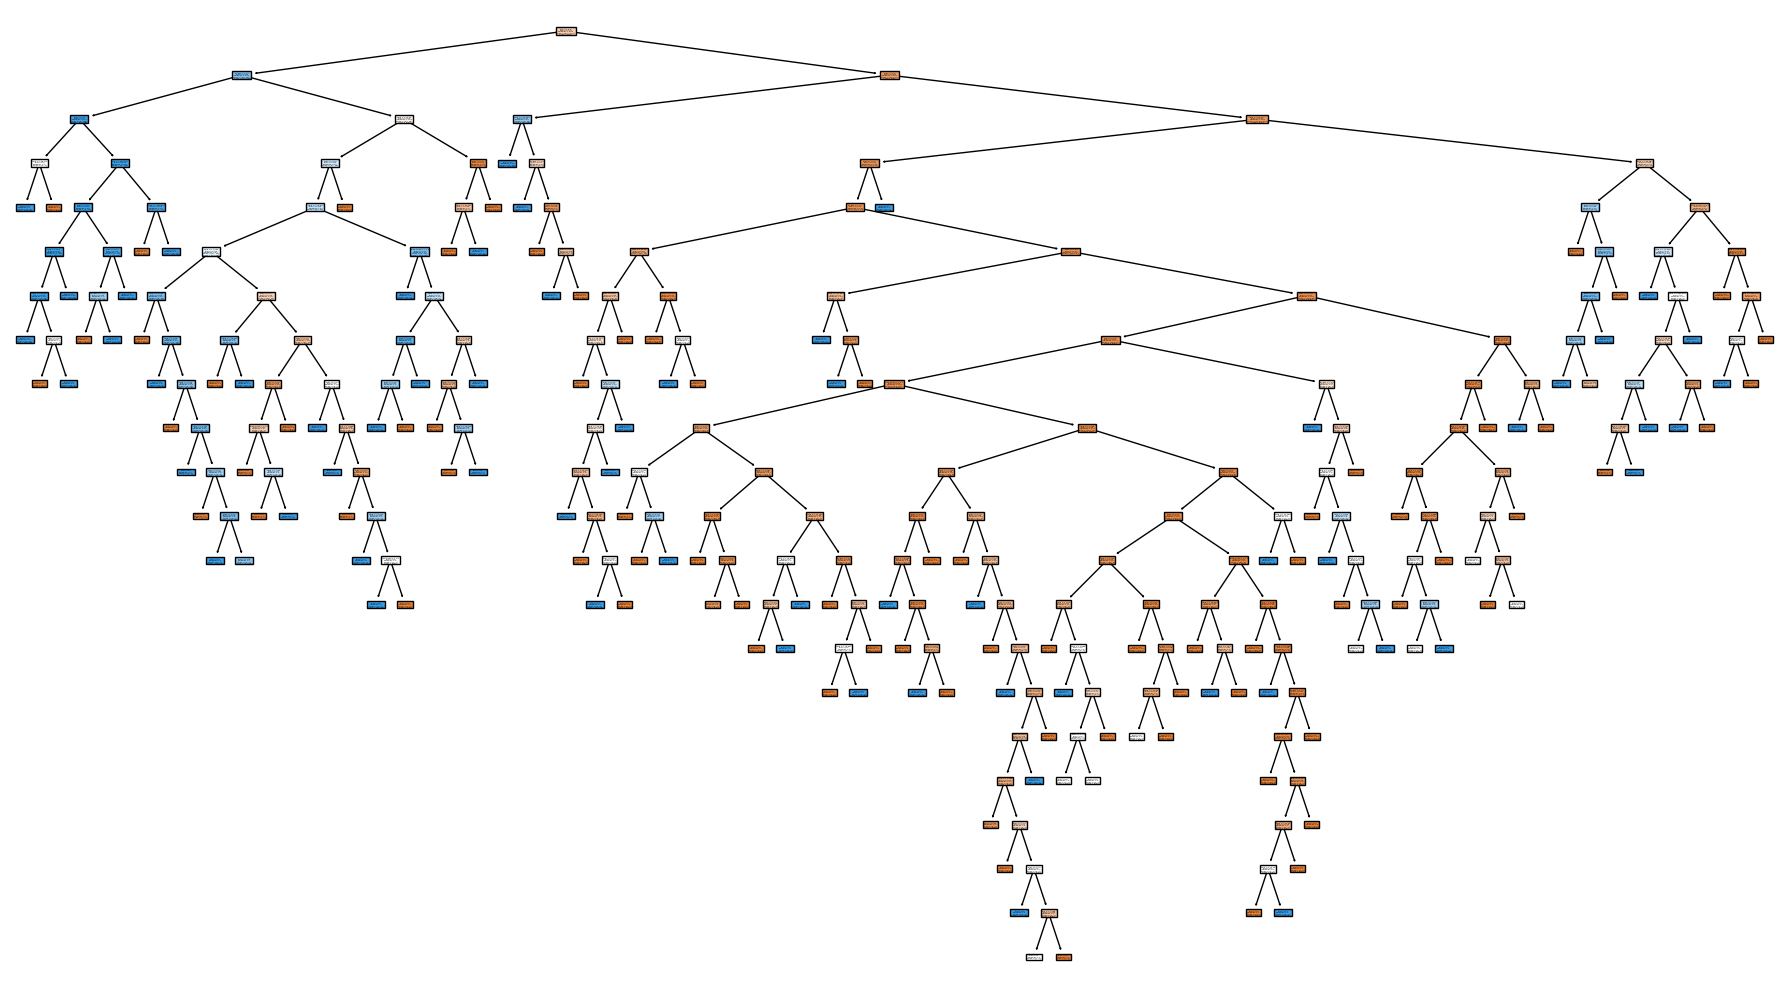

In [25]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)
plt.tight_layout()